## Deakin University

## SIG731- Data Wrangling

**Name:** Surendra Bahadur Rai

**Email:** s223940212@deakin.com

**Student ID:** s223940212

## Task-4p

**Objective**

The nycflights13_weather.csv.gz dataset provides hourly meteorological data for three major airports in New York City (LGA, JFK, and EWR) for the entire year of 2013. The dataset includes various weather-related variables such as temperature, dew point, humidity, wind speed, precipitation, pressure, and visibility. The primary objective of this dataset is to analyze and understand weather patterns at these airports.


- **Study Weather Trends:** Analyze how weather conditions (temperature, wind speed, precipitation) vary over time (daily, monthly ,Hour).

- **Impact on Aviation:** Investigate how weather conditions might affect flight operations, such as delays, cancellations, or safety.

- **Compare Airports**: Compare weather conditions across the three airports (LGA, JFK, and EWR) to identify differences or similarities.

- **Data Cleaning and Preparation:** Address issues like the incorrect time_hour column and outliers in the data, which are common challenges in real-world datasets.


## Importting Library Package

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#Python warning ingorning
import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.notebook_repr_html", False)

In [19]:
weather_df = pd.read_csv("data/nycflights13_weather.csv.gz",comment="#")
weather_df.head()

  origin  year  month  day  hour   temp   dewp  humid  wind_dir  wind_speed  \
0    EWR  2013      1    1     0  37.04  21.92  53.97     230.0    10.35702   
1    EWR  2013      1    1     1  37.04  21.92  53.97     230.0    13.80936   
2    EWR  2013      1    1     2  37.94  21.92  52.09     230.0    12.65858   
3    EWR  2013      1    1     3  37.94  23.00  54.51     230.0    13.80936   
4    EWR  2013      1    1     4  37.94  24.08  57.04     240.0    14.96014   

   wind_gust  precip  pressure  visib            time_hour  
0  11.918651     0.0    1013.9   10.0  2013-01-01 01:00:00  
1  15.891535     0.0    1013.0   10.0  2013-01-01 02:00:00  
2  14.567241     0.0    1012.6   10.0  2013-01-01 03:00:00  
3  15.891535     0.0    1012.7   10.0  2013-01-01 04:00:00  
4  17.215830     0.0    1012.8   10.0  2013-01-01 05:00:00  

**Dataset**

Here is  the nycflights13_weather.csv.gz data file loaded 
It gives the hourly meteorological data for three airports in New York: LGA, JFK, and EWR for
the whole year of 2013. 

**Columns:**

- origin – weather station: LGA, JFK, or EWR,
- year, month, day, hour – time of recording,
- temp, dewp – temperature and dew point in degrees Fahrenheit,
- humid – relative humidity,
- wind_dir, wind_speed, wind_gust – wind direction (in degrees), speed and gust speed (in mph),
- precip – precipitation, in inches,
- pressure – sea level pressure in millibars,
- visib – visibility in miles,
- time_hour – date and hour (based on the year, month, day, hour fields) formatted as YYYY-mm-dd HH:MM:SS (actually, YYYY-mm-dd HH:00:00). 

### Q1. Convert all columns so that they use metric (International System of Units, SI) or derived units: temp and dewp to Celsius, precip to millimetres, visib to metres.


In [20]:
# International System of Units, SI conversions using lambda functions
weather_df['temp'] = weather_df['temp'].apply(lambda x: (x - 32) * 5 / 9)
weather_df['dewp'] = weather_df['dewp'].apply(lambda x: (x - 32) * 5 / 9)
weather_df['precip'] = weather_df['precip'].apply(lambda x: x * 25.4)
weather_df['visib'] = weather_df['visib'].apply(lambda x: x * 1609.34)
weather_df['wind_speed'] = weather_df['wind_speed'].apply(lambda x: x * 0.44704)
weather_df['wind_gust'] = weather_df['wind_gust'].apply(lambda x: x * 0.44704)
# Convert time_hour to datetime
weather_df['time_hour'] = pd.to_datetime(weather_df['time_hour'])
weather_df

      origin  year  month  day  hour  temp  dewp  humid  wind_dir  wind_speed  \
0        EWR  2013      1    1     0   2.8  -5.6  53.97     230.0    4.630002   
1        EWR  2013      1    1     1   2.8  -5.6  53.97     230.0    6.173336   
2        EWR  2013      1    1     2   3.3  -5.6  52.09     230.0    5.658892   
3        EWR  2013      1    1     3   3.3  -5.0  54.51     230.0    6.173336   
4        EWR  2013      1    1     4   3.3  -4.4  57.04     240.0    6.687781   
...      ...   ...    ...  ...   ...   ...   ...    ...       ...         ...   
26125    LGA  2013     12   30    19   2.2  -6.7  51.78     340.0    6.173336   
26126    LGA  2013     12   30    20   1.1  -8.3  49.51     330.0    7.716670   
26127    LGA  2013     12   30    21   0.0  -9.4  49.19     340.0    6.687781   
26128    LGA  2013     12   30    22  -0.6 -10.6  46.74     320.0    7.716670   
26129    LGA  2013     12   30    23  -1.7 -11.7  46.41     330.0    8.231115   

       wind_gust  precip  p

#### Here, I have convert the columns to metric SI units using lamda function  formual is apply like  bellow

**Temperature** Convert from Fahrenheit to Celsius.

$C=(F−32)\frac{9}{5}$

temp and dewp colum has converted


**Precipitation (precip):** Convert from inches to millimeters.

$ mm=inches×25.4$

**Visibility (visib):** Convert from miles to meters.

$meters=miles×1609.34$

Miles are converted to meters by multiplying by 1609.34 (since 1 mile = 1609.34 meters)

**Wind Speed (wind_speed and wind_gust):** Convert from miles per hour (mph) to meters per second (m/s).

**Formula:** 

$m/s= mph × 0.44704$

Miles per hour (mph) are converted to meters per second (m/s) by multiplying by 0.44704 (since 1 mph = 0.44704 m/s).

#### Q2. Compute daily mean wind speeds for the LGA airport (~365 total speed values, for each day separately

In [21]:
# Filter for LGA of Airport
lga_weather = weather_df[weather_df['origin'] == 'LGA']

# Group by year, month, and day, and compute mean wind speed
daily_mean_wind_speed = lga_weather.groupby(['year', 'month', 'day'])['wind_speed'].mean().reset_index()

# Rename the mean column for clarity
daily_mean_wind_speed.rename(columns={'wind_speed': 'mean_wind_speed'}, inplace=True)

# Display the result
print(daily_mean_wind_speed)

     year  month  day  mean_wind_speed
0    2013      1    1         6.687781
1    2013      1    2         6.430559
2    2013      1    3         4.908660
3    2013      1    4         6.880698
4    2013      1    5         5.144447
..    ...    ...  ...              ...
359  2013     12   26         3.301020
360  2013     12   27         5.401669
361  2013     12   28         4.672873
362  2013     12   29         3.794030
363  2013     12   30         6.001855

[364 rows x 4 columns]


- Filter the data for the LGA airport.
- Group the data by year, month, and day.
- Compute the mean wind speed for each day.
- Print the Daily ( each day) Mean wind sepeed

### Q3.Present the daily mean wind speeds at LGA (~365 aforementioned data points) in a single plot, using the matplotlib.pyplot.plot function

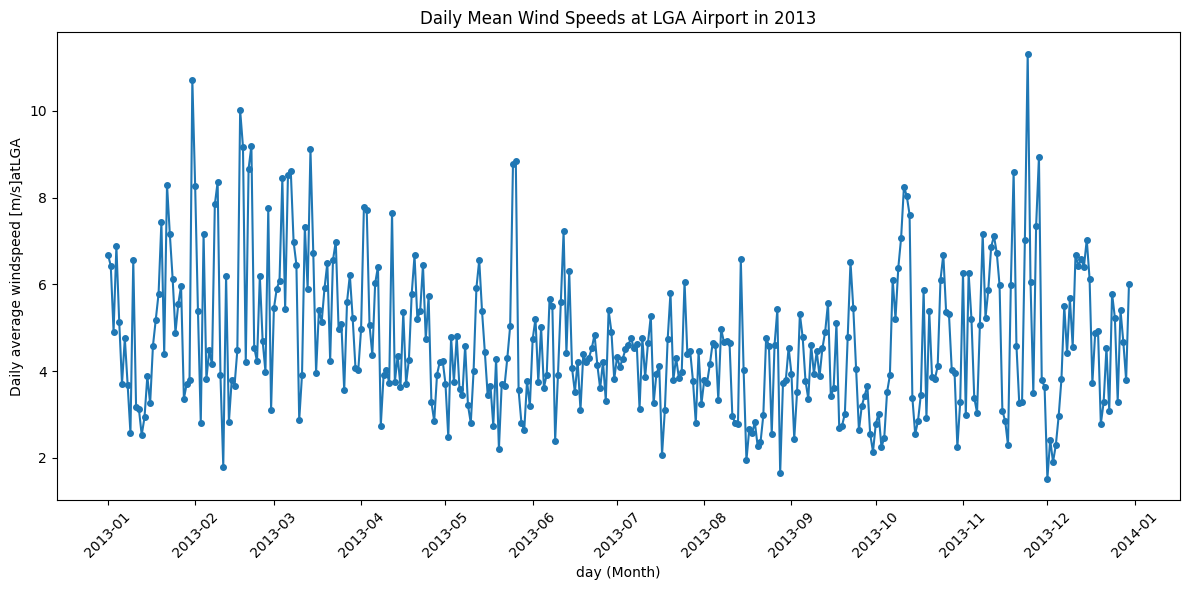

In [22]:
# Filter for LGA airport
lga_weather = weather_df[weather_df['origin'] == 'LGA']

# Group by year, month, and day, and compute mean wind speed
daily_mean_wind_speed = lga_weather.groupby(['year', 'month', 'day'])['wind_speed'].mean().reset_index()

# Create a datetime column for plotting
daily_mean_wind_speed['date'] = pd.to_datetime(daily_mean_wind_speed[['year', 'month', 'day']])

# Plot line grapsh
plt.figure(figsize=(12, 6))
plt.plot(daily_mean_wind_speed['date'], daily_mean_wind_speed['wind_speed'], marker='o', linestyle='-', markersize=4)

# Format x-axis to show month column
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) 
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) 

# Add labels and title
plt.xlabel('day (Month)')
plt.ylabel('Daily average windspeed [m/s]atLGA')
plt.title('Daily Mean Wind Speeds at LGA Airport in 2013')

# Format x-axis to show year and month (YYYY-MM)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) 
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) 

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

Here is step for description

- Filter for LGA airport
- Group by year, month, and day, and compute mean wind speed
- Create a datetime column for plotting
- Plot line grapsh
- Format x-axis to show month column
- Format x-axis to show year and month (YYYY-MM)
- Rotate x-axis labels for better readability
- Show the plot

### Q4. Identify the ten windiest days at LGA (dates and the corresponding mean daily wind speeds).

In [23]:
# Filter for LGA airport
lga_weather = weather_df[weather_df['origin'] == 'LGA']

# Group by year, month, and day, and compute mean wind speed
daily_mean_wind_speed = lga_weather.groupby(['year', 'month', 'day'])['wind_speed'].mean().reset_index()

# New datetime column  add
daily_mean_wind_speed['date'] = pd.to_datetime(daily_mean_wind_speed[['year', 'month', 'day']])

# Sort by mean wind speed in descending order
windiest_days = daily_mean_wind_speed.sort_values(by='wind_speed', ascending=False)

# Format the output
windiest_days = windiest_days[['date', 'wind_speed']].reset_index(drop=True)
windiest_days['date'] = windiest_days['date'].dt.strftime('%Y-%m-%d')

# Display the result
print(windiest_days)


           date  wind_speed
0    2013-11-24   11.317783
1    2013-01-31   10.717598
2    2013-02-17   10.010236
3    2013-02-21    9.192903
4    2013-02-18    9.174264
..          ...         ...
359  2013-08-16    1.945943
360  2013-12-03    1.907732
361  2013-02-11    1.800556
362  2013-08-28    1.650510
363  2013-12-01    1.521899

[364 rows x 2 columns]


### Q5. Compute the monthly mean wind speeds for all the three airports.

In [24]:
# Identify the outlier Calculating InterQuartile
Q1 = weather_df['wind_speed'].quantile(0.25)
Q3 = weather_df['wind_speed'].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier threshold lower bound and upper bound
lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR

# Replace the outlier with NaN
weather_df['wind_speed'] = np.where(
    (weather_df['wind_speed'] < lb) | (weather_df['wind_speed'] > ub),
    np.nan,
    weather_df['wind_speed']
)

# Group by origin, year, and month, and compute mean wind speed
monthly_mean_wind_speed = weather_df.groupby(['origin', 'year', 'month'])['wind_speed'].mean().reset_index()

# Result
print(monthly_mean_wind_speed)

   origin  year  month  wind_speed
0     EWR  2013      1    4.102076
1     EWR  2013      2    4.530279
2     EWR  2013      3    5.010183
3     EWR  2013      4    4.255796
4     EWR  2013      5    3.617888
5     EWR  2013      6    4.167217
6     EWR  2013      7    4.022527
7     EWR  2013      8    3.349452
8     EWR  2013      9    3.574639
9     EWR  2013     10    3.640309
10    EWR  2013     11    4.480718
11    EWR  2013     12    3.911640
12    JFK  2013      1    5.060265
13    JFK  2013      2    5.476453
14    JFK  2013      3    5.935677
15    JFK  2013      4    5.311958
16    JFK  2013      5    4.392293
17    JFK  2013      6    4.866446
18    JFK  2013      7    4.489068
19    JFK  2013      8    4.295648
20    JFK  2013      9    4.350242
21    JFK  2013     10    4.573231
22    JFK  2013     11    5.397103
23    JFK  2013     12    4.842085
24    LGA  2013      1    4.869840
25    LGA  2013      2    5.172713
26    LGA  2013      3    5.672411
27    LGA  2013     

Here is step:

- Identify the outlier Calculating InterQuartile
- Define the outlier threshold lower bound and upper bound
- Replace the outlier with NaN
- Group by origin, year, and month, and compute mean wind speed
- showing monthly_mean_wind_speed result


### Q6. Draw the monthly mean wind speeds for the three airports on the same plot (three curves of different colours). Add a readable legend. Reference result

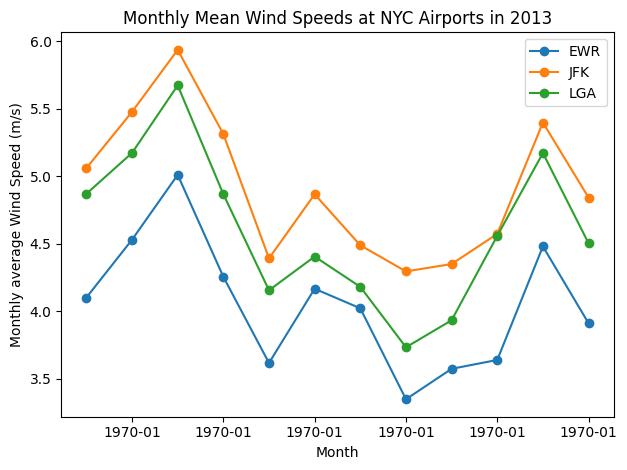

In [17]:
# Group by origin, year, and month, and compute mean wind speed
monthly_mean_wind_speed = weather_df.groupby(['origin', 'year', 'month'])['wind_speed'].mean().reset_index()

#Plot line monthly wind speed
for airport in monthly_mean_wind_speed['origin'].unique():
    data = monthly_mean_wind_speed[monthly_mean_wind_speed['origin'] == airport]
    plt.plot(data['month'], data['wind_speed'], marker='o', label=airport)
    
# x and y label
plt.xlabel('Month')
plt.ylabel('Monthly average Wind Speed (m/s)')
plt.title('Monthly Mean Wind Speeds at NYC Airports in 2013')

# Format x-axis to show year and month (YYYY-MM)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) 

#Legent and showing grapha
plt.legend()
plt.tight_layout()
plt.show()

**Step**

- find the monthly_mean_wind_speed 
- plot line of monthly mean wind speed Iterating the origal Airport
- adding the lable
- Format x-axis to show year and month (YYYY-MM)
- Legent and showing grapha
- 